# Sentiment analysis on movie reviews

In this notebook, we will explore basic NLP techniques to analyze movie reviews using the Large Movie Review Dataset, found in: https://ai.stanford.edu/~amaas/data/sentiment/

In [1]:
from collections import Counter

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

import os

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
import re

In [2]:
def load_imdb_data(path):
    data = []
    labels = []
    for label in ['pos', 'neg']:
        dir_path = f"{path}/{label}"
        for filename in os.listdir(dir_path):
            with open(f"{dir_path}/{filename}", 'r', encoding='utf-8') as file:
                data.append(file.read())
                labels.append(1 if label == 'pos' else 0)
    return pd.DataFrame({'review': data, 'sentiment': labels})

In [3]:
#No me dejaba descargarlo desde su link jajajaj
!wget https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz

!tar -xzf aclImdb_v1.tar.gz

import os
import pandas as pd

def load_imdb_data(data_dir):
    data = {
        "review": [],
        "sentiment": []
    }

    for sentiment in ["pos", "neg"]:
        sentiment_path = os.path.join(data_dir, sentiment)

        for file_name in os.listdir(sentiment_path):
            file_path = os.path.join(sentiment_path, file_name)

            with open(file_path, "r", encoding="utf-8") as f:
                review = f.read()

            data["review"].append(review)
            data["sentiment"].append(1 if sentiment == "pos" else 0)

    return pd.DataFrame(data)

dataset_root = "./aclImdb"

train_df = load_imdb_data(dataset_root + "/train")
test_df = load_imdb_data(dataset_root + "/test")

print(train_df.head())
print(test_df.head())
print(train_df.shape)
print(test_df.shape)

--2026-05-08 06:42:35--  https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
Resolving ai.stanford.edu (ai.stanford.edu)... 171.64.68.10
Connecting to ai.stanford.edu (ai.stanford.edu)|171.64.68.10|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 84125825 (80M) [application/x-gzip]
Saving to: ‘aclImdb_v1.tar.gz’

aclImdb_v1.tar.gz   100%[===================>]  80.23M  46.1MB/s    in 1.7s    

2026-05-08 06:42:37 (46.1 MB/s) - ‘aclImdb_v1.tar.gz’ saved [84125825/84125825]

                                              review  sentiment
0  I may be biased, I am the author of the novel ...          1
1  This musical was not quite what I expected, fo...          1
2  When I started watching "Fay Grim", I had no i...          1
3  Samuel Fuller brings his customary playful and...          1
4  Back to the roots with "like it is in heaven" ...          1
                                              review  sentiment
0  this movie had me stuck in this end

## EDA

Let's take a quick look at the data to understand the distribution of sentiments, the length of reviews, and some common words used in positive vs negative reviews.

<Axes: xlabel='sentiment', ylabel='count'>

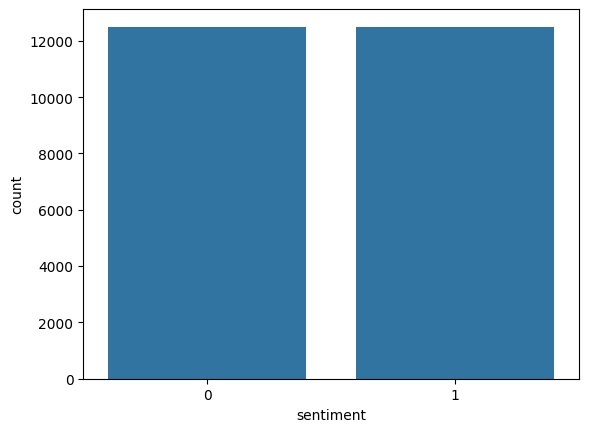

In [4]:
sns.countplot(x='sentiment', data=train_df)

As we can see, the dataset is balanced with an equal number of positive and negative reviews.

Let's now look at the distribution of review lengths. First compute the length of each review, both in terms of characters and words, and then plot the distributions.

In [5]:
n_chars = train_df['review'].apply(len)
n_words = train_df['review'].apply(lambda s: len(s.split()))

review_length_df = pd.DataFrame({'chars': n_chars, 'words': n_words, 'sentiment': train_df['sentiment']})
review_length_df.describe().T

,count,mean,std,min,25%,50%,75%,max
chars,25000.0,1325.06964,1003.133670,52.0,702.0,979.0,1614.0,13704.0
words,25000.0,233.78720,173.733032,10.0,127.0,174.0,284.0,2470.0
sentiment,25000.0,0.50000,0.500010,0.0,0.0,0.5,1.0,1.0


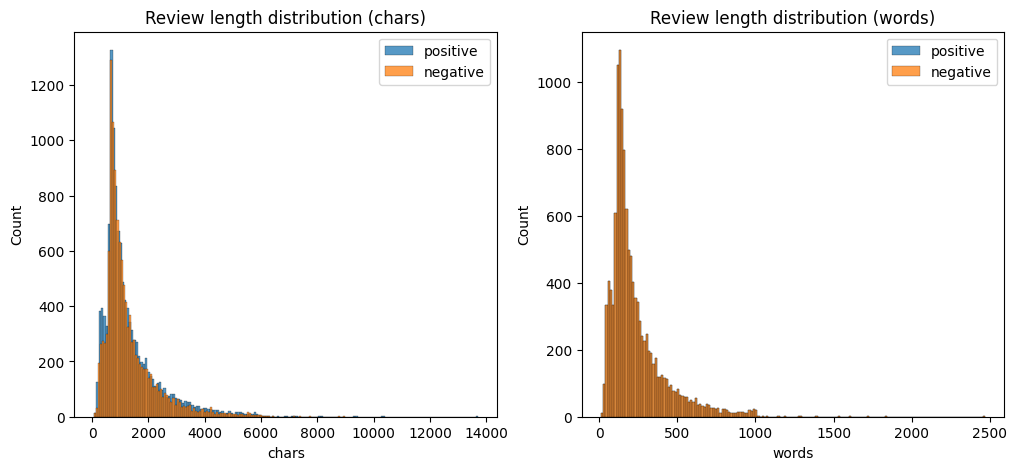

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['chars'], ax=axs[0], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 0]['chars'], ax=axs[0], label='negative')
axs[0].set_title("Review length distribution (chars)")
axs[0].legend()

sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='positive')
sns.histplot(review_length_df[review_length_df['sentiment'] == 1]['words'], ax=axs[1], label='negative')
axs[1].set_title("Review length distribution (words)")
axs[1].legend()

As can be seen, the distribution of review lengths is quite similar for both positive and negative reviews, with most reviews being below 500 words. In terms of characters, most reviews have less than 3000 characters. This can be confirmed with boxplots, which show the "whiskers" of the distribution and any potential outliers.

Text(0.5, 1.0, 'Review length (words) by sentiment')

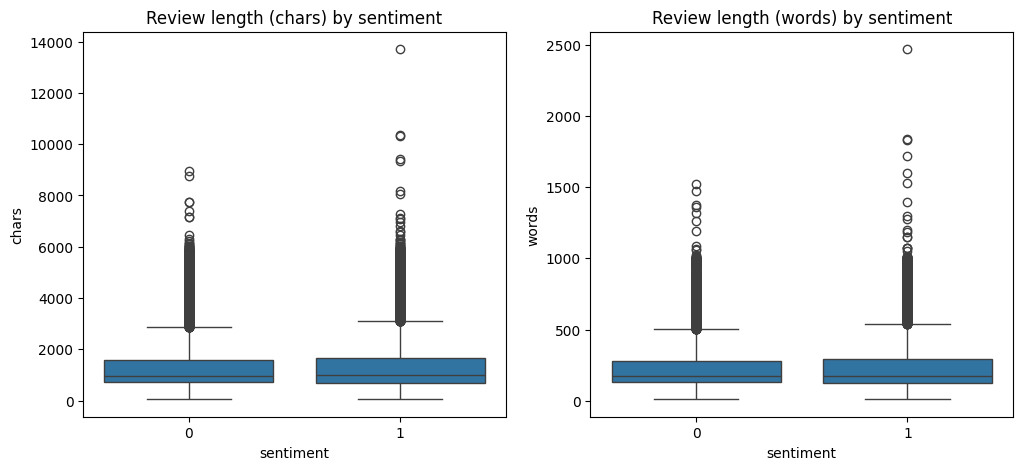

In [7]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='sentiment', y='chars', data=review_length_df, ax=axs[0])
axs[0].set_title("Review length (chars) by sentiment")

sns.boxplot(x='sentiment', y='words', data=review_length_df, ax=axs[1])
axs[1].set_title("Review length (words) by sentiment")

In [8]:
def get_top_words(docs, n=20):
    all_words = ' '.join(docs).split()
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [9]:
print("Top words in positive reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 1]['review']))

print("\nTop words in negative reviews:")
print(get_top_words(train_df[train_df['sentiment'] == 0]['review']))

Top words in positive reviews:
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'that', 'I', 'it', 'this', '/><br', 'as', 'with', 'was', 'for', 'The', 'but', 'his', 'on']

Top words in negative reviews:
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'I', 'that', 'this', 'it', '/><br', 'was', 'for', 'with', 'as', 'but', 'movie', 'The', 'on']


As we can see, the most common words in both positive and negative reviews are quite similar, with words like "the", "and", "a", "is" appearing frequently. Another issue is that this is case-insensitive, so "the" is treated as different that "The". To get a better idea of common words by sentiment, we can normalize the text by converting it to lowercase and removing any punctuation (and numbers, while we are at it).

In [10]:
def normalize_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [11]:
print("Top words in positive reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']]))

print("\nTop words in negative reviews (normalized):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']]))

Top words in positive reviews (normalized):
['the', 'and', 'a', 'of', 'to', 'is', 'in', 'it', 'i', 'this', 'that', 'br', 'as', 'with', 'for', 'was', 'but', 'film', 'movie', 'his']

Top words in negative reviews (normalized):
['the', 'a', 'and', 'of', 'to', 'is', 'in', 'this', 'i', 'it', 'that', 'br', 'was', 'movie', 'for', 'but', 'with', 'as', 'film', 'on']


While most of the common words are still common stop words, at least we are now getting words like "movie" and "film". However, this still doesn't give us a good idea of which words are more associated with positive vs negative reviews.

To deal with this, we will use the NLTK library to remove stop words.

In [12]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [13]:
stopwords = stopwords.words('english')
print(stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

Some of these words are negations, such as "not", "no", "nor", which can be important for sentiment analysis. We will keep these in our list of stop words.

In [14]:
neg_words = [ 'no', 'nor', 'not', 'ain', 'aren', "aren't", 'don', "don't", 'couldn', "couldn't", 'didn', "didn't", 'doesn', "doesn't", 'hadn', "hadn't", 'hasn', "hasn't", 'haven', "haven't", 'isn', "isn't", 'mightn', "mightn't", 'mustn', "mustn't", 'needn', "needn't", 'shan', "shan't", 'shouldn', "shouldn't", 'wasn', "wasn't", 'weren', "weren't", 'won', "won't", 'wouldn', "wouldn't"]

stopwords = [w for w in stopwords if w not in neg_words]

Let's redefine our `get_top_words` function to remove stop words before counting the most common words.

In [15]:
def get_top_words(docs, n=20, exclude=None):
    all_words = ' '.join(docs).split()
    if exclude is not None:
        all_words = [w for w in all_words if w not in exclude]
    count_by_word = Counter(all_words)
    return [w for w, i in count_by_word.most_common(n)]

In [16]:
# Ensure stopwords are processed in the same way as our documents (lowercased and punctuation removed)
norm_stopwords = set([normalize_text(w) for w in stopwords])

print("Top words in positive reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 1]['review']], exclude=norm_stopwords))

print("\nTop words in negative reviews (no stopwords):")
print(get_top_words([normalize_text(t) for t in train_df[train_df['sentiment'] == 0]['review']], exclude=norm_stopwords))

Top words in positive reviews (no stopwords):
['br', 'film', 'movie', 'not', 'one', 'like', 'good', 'story', 'great', 'time', 'see', 'also', 'really', 'would', 'even', 'first', 'much', 'no', 'people', 'films']

Top words in negative reviews (no stopwords):
['br', 'movie', 'film', 'not', 'one', 'like', 'no', 'even', 'good', 'bad', 'would', 'really', 'time', 'see', 'dont', 'get', 'much', 'story', 'people', 'could']


We can now start to see some differences in the most common words between positive and negative reviews. Words like "good" and "great" are more common in positive reviews, while words like "bad" are now more common in negative reviews. That said, there is still a lot of overlap, since words like "movie", "film" and "story" are expected to appear in movie reviews regardless of the sentiment. We will deal with this later.

## Vectorization

We have now done some basic EDA to understand the data. The next step is to convert the text data into a format that can be used for machine learning models. One common approach is to use a bag-of-words representation, where we create a vector for each document that counts the occurrences of each word in the vocabulary. We can use the `CountVectorizer` from the `sklearn` library to do this.

In [17]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words=stopwords, lowercase=True)
x_train = vectorizer.fit_transform(train_df['review'])
x_test = vectorizer.transform(test_df['review'])

Now that we vectorized our text data, let's compare the result with the original text.

In [18]:
print(train_df['review'][0])
print(x_train[0])

I may be biased, I am the author of the novel The Hungry Bachelors Club, self-published in 1994. The screenplay was written by my good friend and hungry bachelor, Fred Dresch, who was the inspiration for the character Marlon in the film. I couldn't be more pleased with the trailer, I hope to see the film in its entirety and I will further comment. But Jorja Fox, who plays Delmar Youngblood, my character, is stellar. She carries the bulk of the emotional vehicles in fine form. I couldn't have done better myself! This looks like real people, hardly formula driven and thankfully drives my statement against racial prejudice home, gracefully and heartfelt.
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 57 stored elements and shape (1, 74726)>
  Coords	Values
  (0, 41455)	1
  (0, 7190)	1
  (0, 5054)	1
  (0, 46065)	1
  (0, 32084)	2
  (0, 5416)	1
  (0, 12961)	1
  (0, 58622)	1
  (0, 52344)	1
  (0, 410)	1
  (0, 58194)	1
  (0, 73722)	1
  (0, 28033)	1
  (0, 26064)	1
  (0, 5414)	1
  (0

We can see that the vectorizer converts every review into a sparse vector of word counts, where the length of the vector is equal to the size of the vocabulary (the number of unique words in the training set after removing stop words). The `fit_transform` method learns the vocabulary from the training data and transforms it into vectors, while the `transform` method uses the same vocabulary to transform the test data.

Each element in the vector corresponds to a word in the vocabulary, and the value of that element is the count of how many times that word appears in the review. Since most reviews will only contain a small subset of the total vocabulary, these vectors are typically very sparse (mostly zeros), which is why they are stored in a sparse format.

Let's get the list of words that are present in the first review and their corresponding counts.

In [19]:
vec = x_train[0].toarray()[0].tolist()
word_count = [(idx, count) for idx, count in enumerate(vec) if count > 0]
print(word_count)

[(410, 1), (5054, 1), (5414, 1), (5416, 1), (7076, 1), (7190, 1), (9565, 1), (10787, 1), (11591, 2), (12961, 1), (13550, 1), (15034, 2), (17345, 1), (19557, 1), (20056, 1), (20121, 1), (20124, 1), (21581, 1), (22053, 1), (24504, 2), (24605, 1), (25553, 1), (25583, 1), (25714, 1), (25919, 1), (26064, 1), (28033, 1), (28282, 1), (29812, 1), (30272, 1), (31352, 1), (31548, 1), (32084, 2), (33814, 1), (35484, 1), (38699, 1), (39320, 1), (40991, 1), (41455, 1), (46065, 1), (49070, 1), (50260, 1), (50289, 1), (51327, 1), (52344, 1), (53050, 1), (53731, 1), (58194, 1), (58506, 1), (58622, 1), (62848, 1), (62999, 1), (66222, 1), (67606, 1), (70857, 1), (73722, 1), (74218, 1)]


The previous cell gives us a list of tuples, where each tuple contains the index of a word in the vocabulary and the count of that word in the first review. To get the actual words, we can use the `get_feature_names_out` method of the vectorizer to get the list of words in the vocabulary and then map the indices to words.

In [20]:
for idx, count in word_count:
    print(f"{vectorizer.get_feature_names_out()[idx]}: {count}")

1994: 1
author: 1
bachelor: 1
bachelors: 1
better: 1
biased: 1
bulk: 1
carries: 1
character: 2
club: 1
comment: 1
couldn: 2
delmar: 1
done: 1
dresch: 1
driven: 1
drives: 1
emotional: 1
entirety: 1
film: 2
fine: 1
form: 1
formula: 1
fox: 1
fred: 1
friend: 1
good: 1
gracefully: 1
hardly: 1
heartfelt: 1
home: 1
hope: 1
hungry: 2
inspiration: 1
jorja: 1
like: 1
looks: 1
marlon: 1
may: 1
novel: 1
people: 1
plays: 1
pleased: 1
prejudice: 1
published: 1
racial: 1
real: 1
screenplay: 1
see: 1
self: 1
statement: 1
stellar: 1
thankfully: 1
trailer: 1
vehicles: 1
written: 1
youngblood: 1


One problem with CountVectorizer is that it gives equal weight to all words, regardless of how common they are across the entire corpus. This can lead to issues where very common words (like "movie", "film", "story") dominate the representation, even though they may not be very informative for distinguishing between positive and negative reviews. To address this, we can use the `TfidfVectorizer`, which stands for Term Frequency-Inverse Document Frequency. This vectorizer gives more weight to words that are more unique to a particular document and less weight to words that are common across all documents.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words=stopwords, lowercase=True)
x_train_tfidf = tfidf_vectorizer.fit_transform(train_df['review'])
x_test_tfidf = tfidf_vectorizer.transform(test_df['review'])

Now let's compare the TF-IDF representation with the original text and the CountVectorizer representation.

In [22]:
review_no_stopwords = ' '.join([w for w in train_df['review'][1].split() if w.lower() not in stopwords])
print("Original review:\n", train_df['review'][1])

print("\nOriginal review (no stopwords):\n", review_no_stopwords)

print("\nAs token IDs:\n", [vectorizer.vocabulary_.get(w.lower(), "-") for w in review_no_stopwords.split()])

Original review:
 This musical was not quite what I expected, foremost being there weren't many scenes between Brando and Sinatra. As it was based on a Damon Runyon story, I expected irony and surprise, of which there was one really good one - when we find that Sinatra's gang has used the Salvation Army office for their crap game while Brando was in Havana with Simmons. If course it comes at the right moment too, when Brando brings her back. I really didn't expect much from Brando as a singer, but he surprised me. He wasn't great but he was just fine in the role. His big number in the sewer, however, with the rest of Sinatra's boys was the only place I felt Brando's voice was weak. He just didn't have the power the grand climax demanded. Overall I found the scenes between Brando and Simmons to be filled with electricity, something I didn't think would happen when we first see Simmons by herself, and later when we're introduced to Brando in the restaurant with Sinatra trying to pull a f

## Training a model

Let's train a simple logistic regression model for this dataset.

To compare models fairly, we will keep the exact same logistic regression hyperparameters across all runs. Since reviews are loaded with all positives first and all negatives after, we will shuffle train/test once before running experiments so quick spot-checks are easier to interpret.

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

RANDOM_STATE = 42

# Ensures dataset is shuffled
train_exp_df = train_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
test_exp_df = test_df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)


In [24]:
def run_experiment(vectorizer, preprocess_fn=None):
    train_text = train_exp_df['review']
    test_text = test_exp_df['review']

    if preprocess_fn is not None:
        train_text = train_text.apply(preprocess_fn)
        test_text = test_text.apply(preprocess_fn)

    x_train_vec = vectorizer.fit_transform(train_text)
    y_train = train_exp_df['sentiment']

    x_test_vec = vectorizer.transform(test_text)
    y_test = test_exp_df['sentiment']

    model = LogisticRegression(solver='liblinear', max_iter=1000, random_state=RANDOM_STATE)
    model.fit(x_train_vec, y_train)
    y_test_pred = model.predict(x_test_vec)
    y_train_pred = model.predict(x_train_vec)

    metrics = {
        'accuracy_train': accuracy_score(y_train, y_train_pred),
        'accuracy_test': accuracy_score(y_test, y_test_pred),
        'precision_train': precision_score(y_train, y_train_pred),
        'precision_test': precision_score(y_test, y_test_pred),
        'recall_train': recall_score(y_train, y_train_pred),
        'recall_test': recall_score(y_test, y_test_pred),
        'f1_train': f1_score(y_train, y_train_pred),
        'f1_test': f1_score(y_test, y_test_pred),
    }

    return model, vectorizer, metrics


In [25]:
experiments = [
    ('CountVectorizer', None, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-norm', normalize_text, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer', None, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-norm', normalize_text, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results = []
model_runs = []
for exp_name, preprocess_fn, vectorizer in experiments:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs.append({
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
results_df


,vectorizer,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test
2,TfidfVectorizer,0.93652,0.88304,0.929950,0.883347,0.94416,0.88264,0.937001,0.882993
3,TfidfVectorizer-norm,0.93720,0.88224,0.931334,0.882730,0.94400,0.88160,0.937624,0.882165
1,CountVectorizer-norm,0.99892,0.86528,0.999040,0.871220,0.99880,0.85728,0.998920,0.864194
0,CountVectorizer,0.99832,0.86356,0.998480,0.869742,0.99816,0.85520,0.998320,0.862410


The table above compares all four configurations using the same logistic regression setup. You can use it to identify whether TF-IDF or CountVectorizer works better here, and whether applying `normalize_text` helps or hurts performance.



We can also look at the most important features for each model to see which words are driving the predictions. For logistic regression, we can look at the coefficients of the model to identify the most influential words for positive and negative sentiment.

As a reminder, a logistic regression model computes scores between 0 and 1 using a linear equation, where each feature has a coefficient. The higher the coefficient, the more that feature contributes to predicting the positive class (sentiment=1), while a lower coefficient contributes to predicting the negative class (sentiment=0). Since each feature represents a word in the vocabulary, we can look at the coefficients to see which words are most strongly associated with positive and negative reviews.

In [26]:
def get_top_features(model, fitted_vectorizer, top_n=10):
    feature_names = fitted_vectorizer.get_feature_names_out()
    coefs = model.coef_[0]

    top_pos_idx = coefs.argsort()[::-1][:top_n]
    top_neg_idx = coefs.argsort()[:top_n]

    top_positive = [(feature_names[idx], coefs[idx]) for idx in top_pos_idx]
    top_negative = [(feature_names[idx], coefs[idx]) for idx in top_neg_idx]
    return top_positive, top_negative

def print_compact_feature_table(model_runs, sentiment='positive', top_n=10):
    table_data = {}

    for run in model_runs:
        top_positive, top_negative = get_top_features(run['model'], run['fitted_vectorizer'], top_n=top_n)
        selected = top_positive if sentiment == 'positive' else top_negative
        table_data[run['name']] = [f"{word} ({coef:.3f})" for word, coef in selected]

    compact_df = pd.DataFrame(table_data, index=[f"#{i}" for i in range(1, top_n + 1)])
    compact_df.index.name = 'rank'
    display(compact_df)

print('Top 10 positive words across experiments')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\nTop 10 negative words across experiments')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

Top 10 positive words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,refreshing (1.552),refreshing (1.626),great (7.241),great (7.296)
#2,wonderfully (1.494),wonderfully (1.455),excellent (6.169),excellent (6.250)
#3,funniest (1.350),funniest (1.376),best (5.193),best (5.278)
#4,superb (1.330),excellent (1.321),perfect (4.840),perfect (4.752)
#5,erotic (1.289),superb (1.308),wonderful (4.671),wonderful (4.648)
#6,excellent (1.282),erotic (1.307),well (4.447),well (4.209)
#7,perfect (1.272),flawless (1.278),amazing (4.227),favorite (4.190)
#8,surprisingly (1.252),perfect (1.220),love (4.059),amazing (4.172)
#9,carrey (1.244),hooked (1.216),favorite (4.057),love (4.104)



Top 10 negative words across experiments


,CountVectorizer,CountVectorizer-norm,TfidfVectorizer,TfidfVectorizer-norm
rank,,,,
#1,disappointment (-2.194),waste (-2.206),worst (-9.195),worst (-9.265)
#2,worst (-2.187),worst (-2.196),bad (-7.509),bad (-7.643)
#3,waste (-2.141),disappointment (-2.133),awful (-6.518),waste (-6.636)
#4,poorly (-1.792),poorly (-1.756),waste (-6.396),awful (-6.410)
#5,awful (-1.658),awful (-1.660),boring (-5.710),boring (-5.490)
#6,lacks (-1.612),lacks (-1.613),poor (-5.322),poor (-5.385)
#7,disappointing (-1.525),forgettable (-1.476),nothing (-4.839),nothing (-4.895)
#8,mess (-1.431),disappointing (-1.453),terrible (-4.783),terrible (-4.828)
#9,unfunny (-1.413),mstk (-1.444),worse (-4.662),worse (-4.702)


## Activity

#### Run 4 new experiments: 2 with CountVectorizer and 2 with TfidfVectorizer. For each vectorizer, apply stemming and lemmatization as the first step of your preprocessing function. Display the models metrics and top features as before.

In [27]:

from nltk.stem import PorterStemmer
import spacy

#aqui solo creamos el objeto
stemmer = PorterStemmer()

#en esta funcion lo que haremos es limpiar el texto usando expresiones regulares
def apply_stemming(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip() #solo quitamos espacios extra q puedan salir
    return ' '.join([stemmer.stem(w) for w in text.split()]) #separamss en palabras todo y aplicamos stemming para despues unirlas

#cargamos el modelo
nlp = spacy.load("en_core_web_sm")


#aqui hacemos lo de lemmatization y convertimos a tokens las palabras que son ahora objetos y tambien obtenemos el lemma d
def apply_lemmatization(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    doc = nlp(text)
    return ' '.join([token.lemma_ for token in doc])

In [ ]:
#Ponemos los experimentos con su nombre, funcion de entrenamiento y el vectorizer con sus parametros, lemmatization y stemming
experiments = [
    ('CountVectorizer-stem', apply_stemming, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('CountVectorizer-lemma', apply_lemmatization, CountVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-stem', apply_stemming, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
    ('TfidfVectorizer-lemma', apply_lemmatization, TfidfVectorizer(stop_words=stopwords, lowercase=True)),
]

results = []
model_runs = []
for exp_name, preprocess_fn, vectorizer in experiments:
    model, fitted_vectorizer, metrics = run_experiment(vectorizer, preprocess_fn=preprocess_fn)
    results.append({
        'vectorizer': exp_name,
        **metrics,
    })
    model_runs.append({ #ejecutamos el pipeline
        'name': exp_name,
        'model': model,
        'fitted_vectorizer': fitted_vectorizer,
    })

results_df = pd.DataFrame(results).sort_values('accuracy_test', ascending=False)
results_df

In [ ]:
print('here are the 10 most positive words hehe')
print_compact_feature_table(model_runs, sentiment='positive', top_n=10)

print('\n here are the 10 most negative words hehe')
print_compact_feature_table(model_runs, sentiment='negative', top_n=10)

#### Which vectorizer and preprocessing combination gives the best performance? Do you see any interesting differences in the top features across the different models?

La mejor combinacion fue el modelo TfidfVectorizer-stem, que usa stemming en el preprocesamiento junto con un vectorizador TF-IDF. Este fue el que dio los resultados mas consistentes y altos de todos los que probe.

Algo interesante que note al revisar las features principales es que, aunque las palabras cambian bastante entre los modelos con stemming y los de lematizacion, igual se pueden ver algunas similitudes entre ellas. Por ejemplo, el stemming te da una version recortada de la palabra, pero igual apunta a lo mismo que su version lematizada mas completa.

Lo mas curioso fue que el modelo agarro palabras como "squirrel" y "serpent" como de las mas frecuentes en resenas positivas, aunque no dicen nada util sobre la peli en si. Esto me hizo pensar que cuando a alguien le gusta una pelicula, tiende a comentar sobre detalles secundarios o cosas al azar que le llamaron la atencion, en lugar de hablar directo del contenido.

#### Write a review for the latest movie that you have seen. Then, use the best performing model to predict the sentiment of your review. Do you agree with the model's prediction? Why or why not?

In [ ]:
review = "Albuquerque is probably the best show I watched last year. The writing is top-notch, the soundtrack is great and the pacing is excellent, it never feels stale."
bad_review = "Albuquerque is the worst thing I have ever seen. The plot is non-existent, the characters are unlikable and the acting is terrible. I can't believe I wasted my time on this."

def predict_review_sentiment(review, model_run):
    vectorizer = model_run['fitted_vectorizer']
    model = model_run['model']
    review_vec = vectorizer.transform([review])
    pred = model.predict(review_vec)[0]
    return pred

tfidf_lemma_run = next(run for run in model_runs if run['name'] == 'TfidfVectorizer-lemma')
print(f"Good review sentiment: {predict_review_sentiment(review, tfidf_lemma_run)}")
print(f"Bad review sentiment: {predict_review_sentiment(bad_review, tfidf_lemma_run)}")

#### Write your final remarks on this activity.

En general, el proyecto me dejo varias cosas claras. Primero, que la forma en que preparas el texto antes de meterlo al modelo importa un monton, el stemming y la lematización pueden darte resuultados distintos aunque estés trabajando con los mismos datos.

También aprendí que los modelos a veces agarran palabras que uno no esperaría, y las marcan como relevantes en reseñas positivas. Eso me enseño q el modelo no entiend el contexto como lo haria una persona, simplemente detecta patrones en los datos, y a veces esos patrones reflejan cosas raras o indirectas del comportamiento humano, como que cuando alguien disfruta una pelicula comenta hasta los detalles más random y pue ottra cosa que me quedó grabada es que no hay una sola forma correcta de hacer las cosas, probar distintas combinaciones de vectorizadores y preprocesamiento es parte del proceso, y comparar los resultados es lo que te ayuda a entender que esta funcionando y por que.